# A/B Testing of Fertilizer Treatments Using Agricultural Field Trial Data

Using historical agricultural field trials, I investigated whether nitrogen fertilizer significantly improves crop yield. The project involves both, Experimental Analysis (A/B Testing), and Predictive Modeling.

How to obtain the dataset:

Type the following commands in R: 
```r
install.packages("agridat") 
library(agridat)
data("heady.fertilizer")
write.csv(heady.fertilizer, "heady_fertilizer.csv", row.names = FALSE) `
```

Use: `help("heady.fertilizer")` to know about the dataset.

Corn crops show a strong positive response on adding nitrogen. Clover naturally fixes nitrogen from the atmosphere. Adding nitrogen may help corn much more than clover. Our analysis will be concentrated around corn.


In [4]:
import pandas as pd
import numpy as np

## Dataset Description

In [5]:
import pandas as pd

df = pd.read_csv("heady_fertilizer.csv")

print(df.shape)
print(df.head())
print(df.info())

(648, 6)
   crop  rep   P  K  N  yield
0  corn    1   0  0  0   24.5
1  corn    2   0  0  0    6.2
2  corn    1  40  0  0   26.7
3  corn    2  40  0  0   29.6
4  corn    1  80  0  0   22.1
<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   crop    648 non-null    str    
 1   rep     648 non-null    int64  
 2   P       648 non-null    int64  
 3   K       648 non-null    int64  
 4   N       648 non-null    int64  
 5   yield   456 non-null    float64
dtypes: float64(1), int64(4), str(1)
memory usage: 30.5 KB
None


About 192 rows have missing yield values.

In [6]:
df.describe()

,rep,P,K,N,yield
count,648.000000,648.000000,648.00000,648.00000,456.000000
mean,1.500000,160.000000,80.00000,80.00000,31.461031
std,0.500386,103.359339,108.40419,108.40419,42.299215
min,1.000000,0.000000,0.00000,0.00000,1.140000
25%,1.000000,80.000000,0.00000,0.00000,3.500000
50%,1.500000,160.000000,0.00000,0.00000,4.185000
75%,2.000000,240.000000,160.00000,160.00000,47.900000
max,2.000000,320.000000,320.00000,320.00000,144.900000


In [7]:
df["crop"].value_counts()

crop
corn       162
clover     162
alfalfa    162
corn2      162
Name: count, dtype: int64

## Data cleaning

#### Missing values and Crop selection

In [8]:
df.isnull().sum()

crop       0
rep        0
P          0
K          0
N          0
yield    192
dtype: int64

In [9]:
df_clean = df.dropna(subset=["yield"])

In [10]:
df_clean.isnull().sum()

crop     0
rep      0
P        0
K        0
N        0
yield    0
dtype: int64

In [11]:
print(df_clean["N"].unique())
print(df_clean["P"].unique())
print(df_clean["K"].unique())

[  0  40  80 120 160 200 240 280 320]
[  0  40  80 120 160 200 240 280 320]
[  0  40  80 120 160 200 240 280 320]


In [12]:
df_clean.groupby("crop").agg({
    "yield":["count","mean","std","min","max"]
})

yield                                    
        count       mean        std   min     max
crop                                             
alfalfa   114   3.299386   0.513698  1.14    4.02
clover    114   3.445614   0.397492  2.29    4.31
corn      114  86.069298  46.345284  4.20  144.90
corn2     114  33.029825  21.289596  3.70   76.70

The yield values do not all have the same physical units.

From the dataset description:

Corn yield is in bushels per acre (bu/acre).
Alfalfa and Clover yields are in tons per acre.

In [13]:
corn = df_clean[df_clean["crop"]=="corn"]

print(corn["N"].unique())

print(corn.groupby("N")["yield"].describe())

[  0  40  80 120 160 200 240 280 320]
     count        mean        std   min      25%     50%      75%    max
N                                                                       
0     18.0   26.650000  10.875512   5.3   21.950   28.50   34.150   44.2
40    10.0   60.660000  28.256492  11.8   42.525   69.85   81.000   96.2
80    10.0   86.630000  38.000791   6.4   87.000  100.85  108.400  116.9
120   10.0  103.590000  42.832113  24.5  102.825  122.95  128.425  135.7
160   18.0  104.094444  37.135119   4.2  103.325  116.10  127.150  134.4
200   10.0   97.660000  50.041565   7.3   95.400  110.60  135.550  142.2
240   10.0  101.790000  48.257284   6.8  112.850  122.70  126.875  139.5
280   10.0  106.030000  48.028049   7.7  112.650  126.40  131.350  142.5
320   18.0  105.272222  36.734994  19.0   82.250  120.75  128.725  144.9


Nitrogen seems enormously important, looking at the mean values. No Nitrogen, average yield: 26.65. the yield stops increasing much after a level of added Nitrogen.

## A/B Testing
#### Exploratory data analysis, Control vs treatment, Welch t-test, Confidence interval and Cohen's d

In [14]:
control = corn[corn["N"] == 0]

treatment = corn[corn["N"] > 0]

In [15]:
print(control.shape)
print(treatment.shape)

print(control["yield"].mean())
print(treatment["yield"].mean())

(18, 6)
(96, 6)
26.65
97.21041666666667


In this experiment, plots receiving nitrogen fertilizer produced approximately 3.65 times higher corn yields than plots receiving no nitrogen fertilizer.

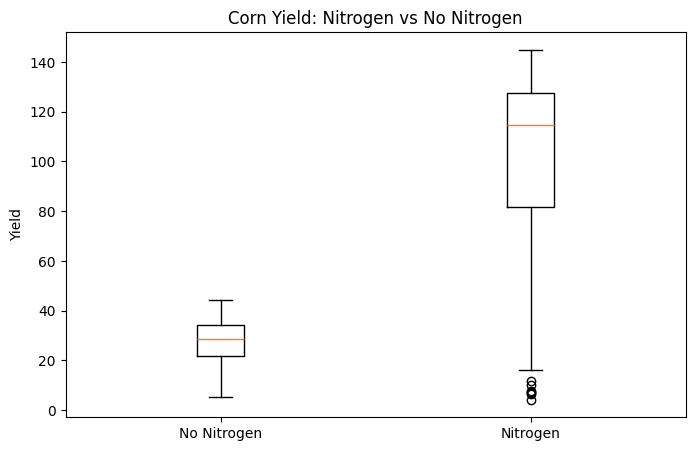

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    [control["yield"], treatment["yield"]],
    tick_labels=["No Nitrogen", "Nitrogen"]
)

plt.ylabel("Yield")
plt.title("Corn Yield: Nitrogen vs No Nitrogen")

plt.show()

The boxplot tells, no Nitrogen group is mostly between roughly 20–35. Nitrogen group is mostly between roughly 80–130.

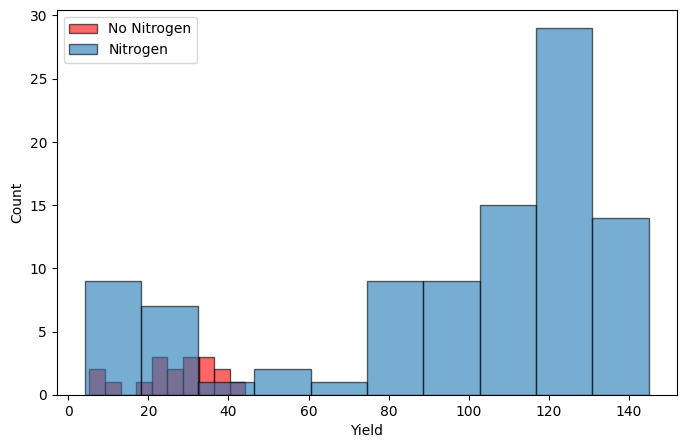

In [17]:
plt.figure(figsize=(8,5))

plt.hist(control["yield"], alpha=0.6, label="No Nitrogen", color= "red", edgecolor="black",)
plt.hist(treatment["yield"], alpha=0.6, label="Nitrogen",edgecolor="black",)

plt.xlabel("Yield")
plt.ylabel("Count")
plt.legend()

plt.show()

The histogram shows, control group is mostly between 5 and 45 while treatment group is mostly between 80 and 145. There is very little overlap. This is why the effect is so obvious.

In [18]:
#Then perform the actual A/B test

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    treatment["yield"],
    control["yield"],
    equal_var=False
)

print("t-statistic =", t_stat)
print("p-value =", p_value)

t-statistic = 14.200819103055876
p-value = 7.09570473576069e-26



#### Hypotheses:

The null hypothesis ($H_0$) assumes no difference:

$$
H_0 : \mu_{\text{Nitrogen}} = \mu_{\text{NoNitrogen}}
$$

The alternative hypothesis ($H_1$) assumes Nitrogen fertilizer increases yield:

$$
H_1 : \mu_{\text{Nitrogen}} > \mu_{\text{NoNitrogen}}
$$

The t-statistic is big and p-value is essentially zero. There is a strong evidence for the rejection of the null hypothesis.

In [19]:
import statsmodels.stats.api as sms

ci_low, ci_high = sms.CompareMeans(
    sms.DescrStatsW(treatment["yield"]),
    sms.DescrStatsW(control["yield"])
).tconfint_diff()

print(ci_low, ci_high)

50.89460230924807 90.22623102408527


This gives us the confidence interval of the yield ([lower,upper]). Interpretation of confidence interval is, for the nitrogen levels present in this experiment (40–320 lb/acre), plots receiving nitrogen had an average yield increase between roughly 58 and 83 units compared with plots receiving no nitrogen. Hence we can say, corn plots receiving nitrogen fertilizer produced, on average, 70.6 additional yield units compared with plots receiving no nitrogen fertilizer. The estimated increase was statistically significant, and the 95% confidence interval ranged from 50.9 to 90.2 yield units.

In [20]:
import numpy as np

mean_t = treatment["yield"].mean()
mean_c = control["yield"].mean()

std_t = treatment["yield"].std()
std_c = control["yield"].std()

n_t = len(treatment)
n_c = len(control)

pooled_std = np.sqrt(
    ((n_t-1)*std_t**2 + (n_c-1)*std_c**2)
    /(n_t+n_c-2)
)

d = (mean_t - mean_c)/pooled_std

print(d)

1.8259788335045861


#### Calculating Cohen's d: it tells how many standard deviations apart are the mean.

#### The formula for d:


$$
d = \frac{\text{difference in means}}{\text{typical spread}}
$$

or,

$$
d = \frac{\bar{x}_T - \bar{x}_C}{s_{\text{pooled}}}
$$

Here, numerator = treatment mean minus control mean ($\bar{x}_T - \bar{x}_C$), and denominator = pooled standard deviation ($s_{\text{pooled}}$).

Cohen's d = 1.83 is very large in magnitude.

#### Summarizing:

Corn plots receiving nitrogen fertilizer produced substantially higher yields than untreated plots. The average increase was approximately 70.6 yield units (95% CI: 50.9–90.2). The effect was highly statistically significant (Welch's t-test ≈ 14.2, p ≈ 7×10⁻²⁶) and very large in magnitude (Cohen's d = 1.83).

## Dose-response analysis
#### Mean yield by nitrogen level and diminishing returns

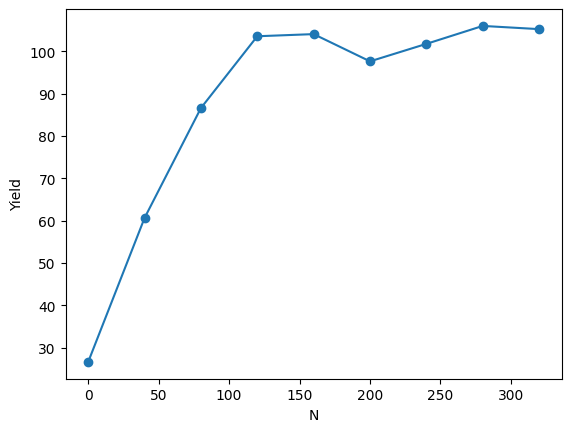

In [35]:
corn.groupby("N")["yield"].mean().plot(
    marker="o"
)
plt.xlabel("N")
plt.ylabel("Yield")
plt.show()


Corn yield increased substantially with nitrogen application up to approximately 120 lb/acre. Beyond this level, additional nitrogen produced little further increase in average yield, suggesting diminishing marginal returns.

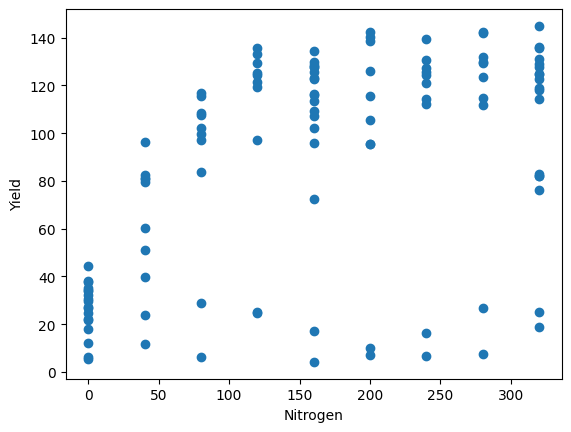

In [34]:
plt.scatter(corn["N"], corn["yield"])
plt.xlabel("Nitrogen")
plt.ylabel("Yield")
plt.show()

If nitrogen were the only thing affecting yield, we would expect same nitrogen giving similar yields. But we are seeing same nitrogen giving sometimes yield = 20 and sometimes 140. That's a big difference. Nitrogen alone cannot explain that. We are seeing evidence that Yield=f(N,P,K), not merely f(N).

## Regression modeling
#### Linear model, Polynomial model and Multiple regression

In [24]:
from sklearn.linear_model import LinearRegression

X = corn[["N"]]
y = corn["yield"]

model = LinearRegression()
model.fit(X, y)

print("Intercept =", model.intercept_)
print("Slope =", model.coef_[0])
print("R² =", model.score(X, y))

Intercept = 52.116961797015904
Slope = 0.21220210280373833
R² = 0.2540993639830431


R² answers much of the variation in yield can be explained by nitrogen alone. R²=0.254 means, Nitrogen alone explains about 25% of the variation in yield.

In [25]:
from sklearn.linear_model import LinearRegression

X = corn[["N", "P", "K"]]
y = corn["yield"]

model = LinearRegression()
model.fit(X, y)

print("Intercept =", model.intercept_)
print("Coefficients =", model.coef_)
print("R² =", model.score(X, y))

Intercept = 17.800949621760807
Coefficients = [0.20811686 0.21856032 0.        ]
R² = 0.5235598393721963


When we added phosphorus and potassium R² = 0.524. It Means together, N, P and K explain about 52% of the variation which is a big improvement. The model is: Yield=17.8+0.208N+0.219P+0×K.

Interpretation is that holding everything else fixed, increasing nitrogen by 1 pound/acre increases predicted yield by about 0.208 units. Holding everything else fixed, increasing phosphorus by 1 pound/acre increases predicted yield by about 0.219 units. Potassium coefficient=0 which implies that we don't find evidence that potassium contributes anything useful for predicting corn yield in this dataset.

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = corn[["N"]]

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

model = LinearRegression()

model.fit(X_poly, y)

print("R² =", model.score(X_poly, y))
print("Coefficients =", model.coef_)
print("Intercept =", model.intercept_)

R² = 0.3615898609173397
Coefficients = [ 0.68099603 -0.00146498]
Intercept = 32.21378095157331


The quadratic model reveals Yield=32.21+0.681N−0.001465$N^2$. Linear model had $R^2$ =0.254 while Quadratic model has $R^2$ =0.362. There is an improvement of 0.362−0.254=0.108, which is a substantial improvement. The analysis tells us that curved relationship describes yield better than a straight line. However, the model N + P + K still performs much better with $R^2$ =0.524 than N + N^2 with $R^2$ =0.362. This implies the biggest limitation was not linearity but missing variables. We were ignoring phosphorus and potassium.


C:\Users\lenovo\anaconda3\envs\tf_env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


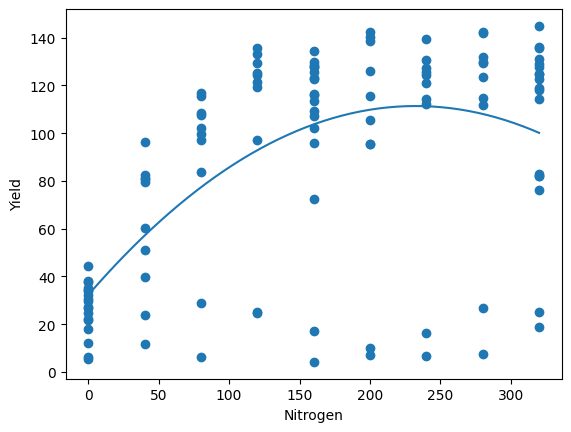

In [28]:
import numpy as np
import matplotlib.pyplot as plt

N_vals = np.linspace(corn["N"].min(),
                     corn["N"].max(),
                     200)

N_poly = poly.transform(
    N_vals.reshape(-1,1)
)

pred = model.predict(N_poly)

plt.scatter(corn["N"], corn["yield"])

plt.plot(N_vals, pred)

plt.xlabel("Nitrogen")
plt.ylabel("Yield")

plt.show()

The smooth curve is my model, Yield=32.21+0.681N−0.001465$N^2$. The model is trying to summarize the overall trend hidden inside all the noisy measurements. Looking at the vertical spread, at N = 160

Notice that the fitted curve starts decreasing after about N ≈ 230 but we cannot conclude more nitrogen actually reduces yield. Our highest nitrogen levels have relatively few observations, and the spread is large. The downward bend is partly the quadratic model trying to fit the data. A more flexible model might instead show a plateau rather than a decline. We might need to use more sophisticated response curves than simple quadratics.

## Conclusions

Corn yield increased substantially with nitrogen application. A quadratic regression model revealed diminishing returns, with rapid yield gains at low nitrogen levels and a plateau at higher levels. While nitrogen alone explained approximately 25% of yield variability, incorporating nonlinear effects improved model performance to 36%. A multiple regression model including phosphorus and potassium further increased explanatory power to 52%, indicating that factors beyond nitrogen contribute substantially to crop productivity.